In [61]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, HTML

In [62]:
import scanpy as sc
import pandas as pd
import numpy as np

adata = sc.read_10x_mtx(
    "../../data/peripheral_blood_mononuclear_cells_10x_genomics/filtered_feature_bc_matrix/",
    var_names='gene_symbols',
    cache=True
)

adata

AnnData object with n_obs × n_vars = 11769 × 33538
    var: 'gene_ids', 'feature_types'

In [63]:
data_path = os.path.join("..","..", "data")
glioblastoma_norm_file = os.path.join(data_path, "glioblastoma_normalized.h5ad")
glioblastoma_raw_file = os.path.join(data_path, "glioblastoma_raw.h5ad")
pbmc3k_file = os.path.join(data_path, "pbmc3k.h5ad")

adata_glioblastoma_norm = sc.read_h5ad(glioblastoma_norm_file)
adata_glioblastoma_raw = sc.read_h5ad(glioblastoma_raw_file)
adata_pbmc3k = sc.read_h5ad(pbmc3k_file)

c:\Users\labsy\anaconda3\envs\vs_env\Lib\site-packages\anndata\_io\h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
c:\Users\labsy\anaconda3\envs\vs_env\Lib\site-packages\anndata\_io\h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


## Dataset: pbmc3k
This dataset contains information about gene expression in peripheral blood mononuclear cells (PBMC). Each row represents a gene, and the columns contain statistics about its expression across different cells.


### 🔍 Variables in the dataset

| **Variable**             | **Description** |
|------------------------|-------------|
| `gene_ids`        | Unique gene identifier in Ensembl format (`ENSGxxxxxxxxxxx`). |
| `n_cells_by_counts` | Number of cells in which the gene was detected. |
| `mean_counts`      | Mean expression value of the gene across all cells. |
| `log1p_mean_counts` | Log-transformed (`log1p`) mean expression of the gene. |
| `pct_dropout_by_counts` | Percentage of cells where the gene was not expressed (`dropout`). |
| `total_counts`     | Total sum of expression values for the gene across all cells. |
| `log1p_total_counts` | Log-transformed (`log1p`) total expression count. |
| `n_cells`         | Total number of cells in which gene expression was measured. |
| `highly_variable` | Indicates whether the gene is highly variable (`True/False`), useful for feature selection. |
| `means`          | Mean gene expression in the sample, without log transformation. |
| `dispersions`     | Dispersion of the gene expression across all cells. |
| `dispersions_norm` | Normalized dispersion of the gene, adjusted by the mean. |

### HEAD of data observed

| index              | n_genes_by_counts | log1p_n_genes_by_counts | total_counts | log1p_total_counts | pct_counts_in_top_50_genes | pct_counts_in_top_100_genes | pct_counts_in_top_200_genes |
|-------------------|-------------------|--------------------------|--------------|--------------------|-----------------------------|------------------------------|------------------------------|
| AAACATACACACCAC-1 | 781               | 6.661855                 | 2421.0       | 7.792349           | 47.748864                   | 63.279637                    | 74.969021                    |
| AAACATTGAGCTAC-1  | 1352              | 7.210080                 | 4903.0       | 8.497807           | 45.502753                   | 61.023863                    | 71.813176                    |
| AAACATTGATCAGC-1  | 1131              | 7.031741                 | 3149.0       | 8.055158           | 41.314703                   | 53.794856                    | 65.449349                    |
| AAACCGTGCTTCCG-1  | 960               | 6.867974                 | 2639.0       | 7.878534           | 39.029936                   | 52.898825                    | 66.691929                    |
| AAACCGTGTATGCG-1  | 522               | 6.259581                 | 981.0        | 6.889591           | 44.852192                   | 55.657492                    | 67.176351                    |

## Dataset: periphereal blood mononuclear cells 10x genomics
### 🔍 Variables in the dataset

| **Variable**                     | **Description** |
|--------------------------------|----------------|
| n_genes                        | Number of genes detected per cell (non-zero counts). |
| total_counts                   | Total expression counts per cell (library size). |
| n_genes_by_counts              | Number of genes with at least one count in the cell. |
| log1p_n_genes_by_counts        | Log-transformed (log1p) number of detected genes per cell. |
| log1p_total_counts             | Log-transformed (log1p) total counts per cell. |
| pct_counts_in_top_50_genes     | Percentage of counts coming from the top 50 most expressed genes in the cell. |
| pct_counts_in_top_100_genes    | Percentage of counts coming from the top 100 most expressed genes in the cell. |
| pct_counts_in_top_200_genes    | Percentage of counts coming from the top 200 most expressed genes in the cell. |
| pct_counts_in_top_500_genes    | Percentage of counts coming from the top 500 most expressed genes in the cell. |
| total_counts_mt                | Total counts from mitochondrial genes per cell. |
| log1p_total_counts_mt          | Log-transformed (log1p) mitochondrial counts per cell. |
| pct_counts_mt                  | Percentage of total counts derived from mitochondrial genes. |


In [64]:
adata.obs["n_genes"] = np.array((adata.X > 0).sum(axis=1)).flatten()
adata.obs["total_counts"] = np.array(adata.X.sum(axis=1)).flatten()

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

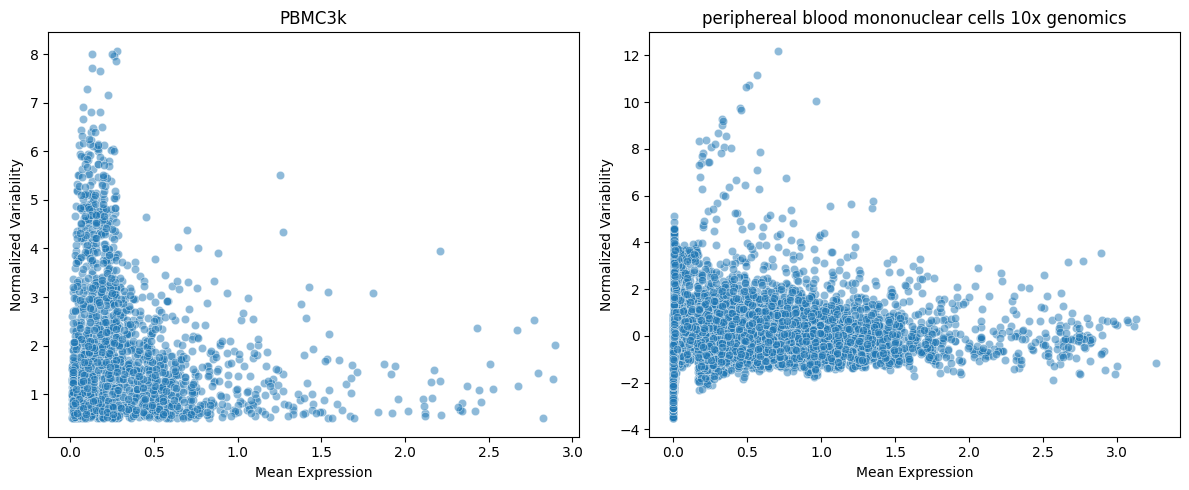

In [74]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
# Crear matriz de plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 → pbmc3k
sns.scatterplot(
    data=adata_pbmc3k.var,
    x="means",
    y="dispersions_norm",
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("PBMC3k")
axes[0].set_xlabel("Mean Expression")
axes[0].set_ylabel("Normalized Variability")

# Plot 2 → tu dataset
sns.scatterplot(
    data=adata.var,
    x="means",
    y="dispersions_norm",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("periphereal blood mononuclear cells 10x genomics")
axes[1].set_xlabel("Mean Expression")
axes[1].set_ylabel("Normalized Variability")

plt.tight_layout()
plt.show()

In [76]:
import numpy as np

# media por gen (axis=0 → columnas = genes)
adata.var["mean_counts"] = np.array(adata.X.mean(axis=0)).flatten()
adata.var["pct_dropout_by_counts"] = (
    np.array((adata.X == 0).sum(axis=0)).flatten() / adata.n_obs * 100
)

C:\Users\labsy\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3699: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [77]:
adata.var.head()

,gene_ids,feature_types,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm
MIR1302-2HG,ENSG00000243485,Gene Expression,False,0,0.000000,0.000000,100.000000,0.000000,0.000000,False,1.000000e-12,NaN,NaN
FAM138A,ENSG00000237613,Gene Expression,False,0,0.000000,0.000000,100.000000,0.000000,0.000000,False,1.000000e-12,NaN,NaN
OR4F5,ENSG00000186092,Gene Expression,False,0,0.000000,0.000000,100.000000,0.000000,0.000000,False,1.000000e-12,NaN,NaN
AL627309.1,ENSG00000238009,Gene Expression,False,60,0.007097,0.004157,99.486242,49.024914,3.912521,False,1.652644e-02,1.383733,-0.102907
AL627309.3,ENSG00000239945,Gene Expression,False,4,0.000435,0.000241,99.965169,2.841244,1.345796,False,8.996955e-04,1.047880,-0.863332


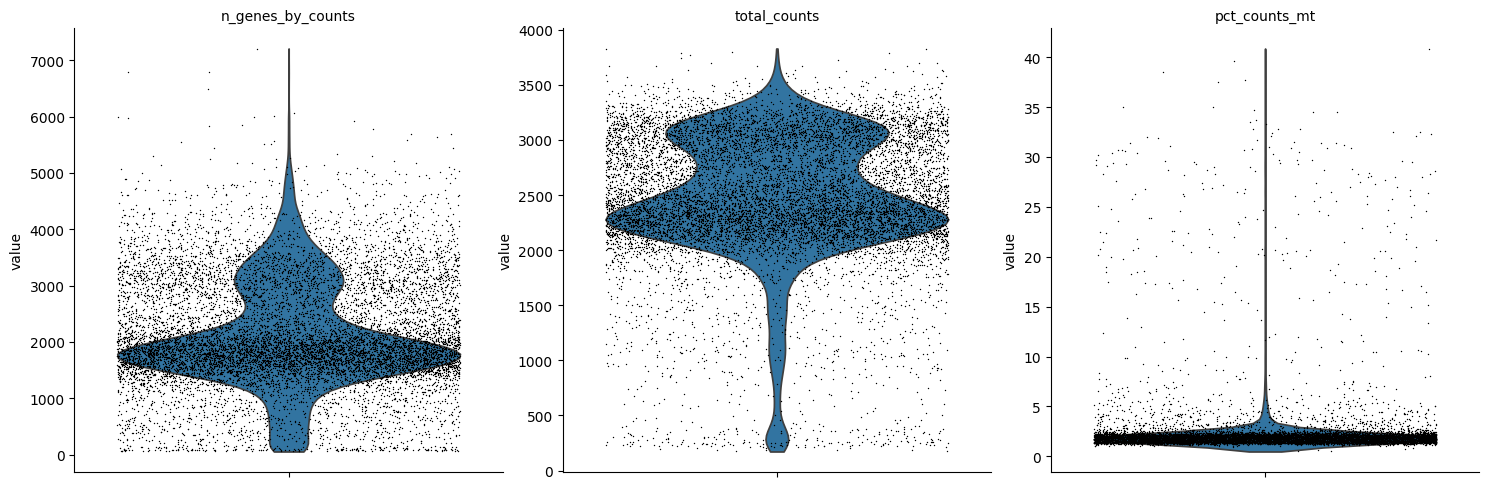

In [67]:
adata.obs['n_genes'] = (adata.X > 0).sum(axis=1)
adata.obs['total_counts'] = adata.X.sum(axis=1)
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

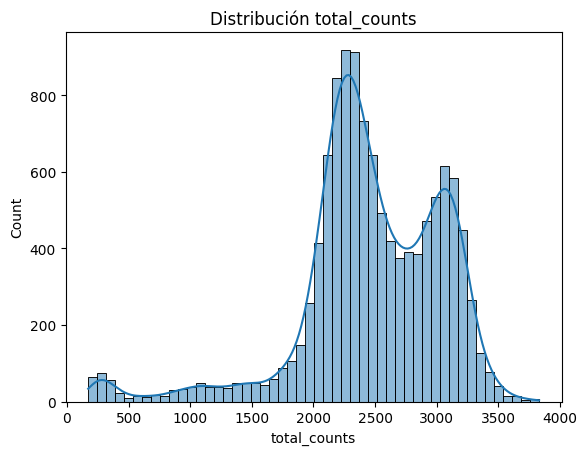

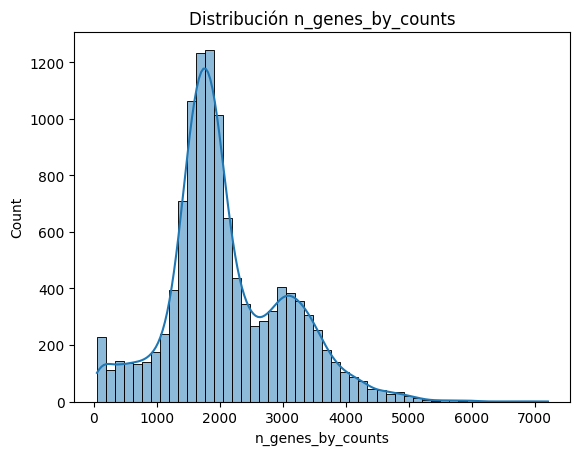

In [68]:
import seaborn as sns;import matplotlib.pyplot as plt

sns.histplot(adata.obs['total_counts'], bins=50, kde=True)
plt.title("Distribución total_counts")
plt.show()

sns.histplot(adata.obs['n_genes_by_counts'], bins=50, kde=True)
plt.title("Distribución n_genes_by_counts")
plt.show()

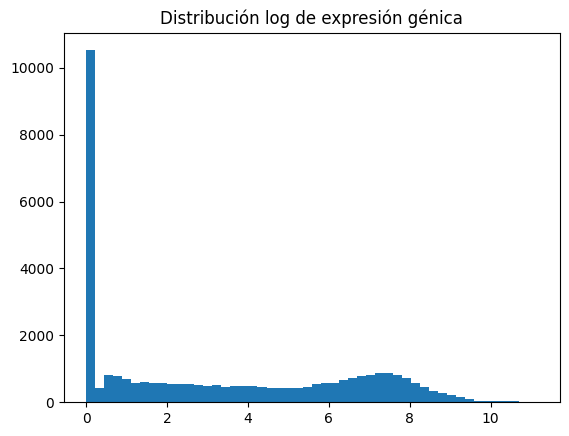

In [69]:
import matplotlib.pyplot as plt

counts = adata.X.sum(axis=0).A1
plt.hist(np.log1p(counts), bins=50)
plt.title("Distribución log de expresión génica")
plt.show()

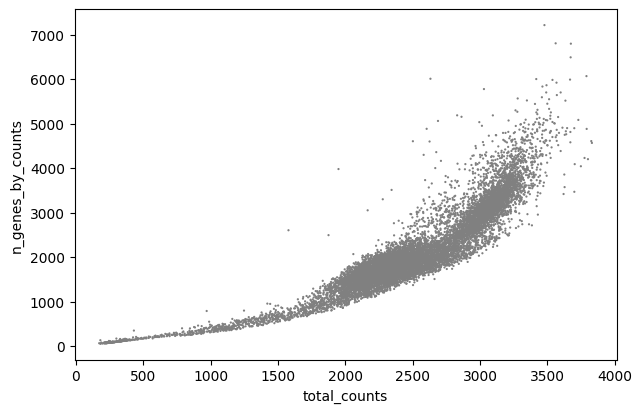

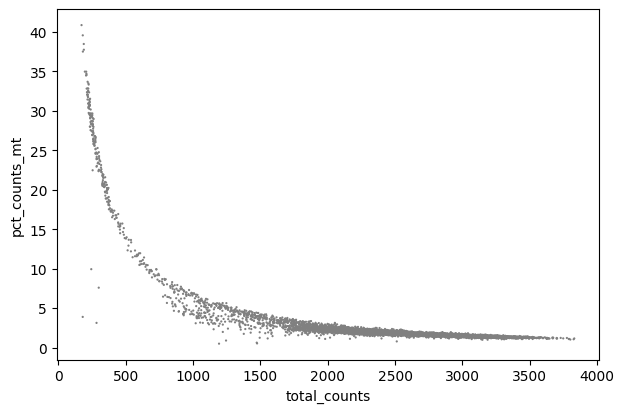

In [70]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')

In [71]:
adata = adata[
    (adata.obs.n_genes_by_counts > 200) &
    (adata.obs.n_genes_by_counts < 5000) &
    (adata.obs.pct_counts_mt < 20),
    :
]

In [72]:
import numpy as np

sparsity = 1 - (adata.X.count_nonzero() / (adata.shape[0] * adata.shape[1]))
print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9364


C:\Users\labsy\AppData\Local\Temp\ipykernel_30680\1083831607.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pl.highest_expr_genes(adata, n_top=20)


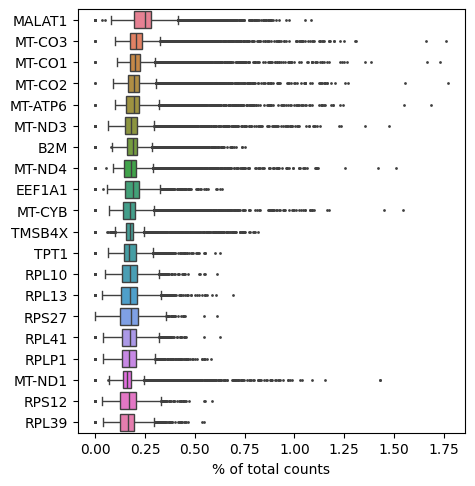

In [73]:
sc.pl.highest_expr_genes(adata, n_top=20)